# S&P 500 Daily Direction Prediction Project

## Introduction & Objective
The primary objective of this project is to build, evaluate, and backtest a machine learning pipeline capable of predicting the daily price movement of the S&P 500 index (`^GSPC`). This is formulated as a **binary classification** task where the target variable represents whether the S&P 500 index closes higher tomorrow compared to today's closing price:
- **`1`**: S&P 500 close price increases tomorrow.
- **`0`**: S&P 500 close price stays the same or decreases tomorrow.

## Project Outline
1. **Data Acquisition & Exploration**: Downloading historical market data using the `yfinance` library.
2. **Data Cleaning & Visualization**: Removing unnecessary columns and inspecting historical index trends.
3. **Target Setup**: Creating features to predict tomorrow's direction based on today's closing price.
4. **Initial Model Training & Evaluation**: Fitting a baseline Random Forest Classifier and calculating precision scores.
5. **Backtesting Framework**: Setting up a rolling window backtest to evaluate historical performance.
6. **Feature Engineering**: Creating rolling average ratios and trend indicators across multiple horizons (2, 5, 60, 250, and 1000 days).
7. **Model Optimization**: Adjusting decision thresholds (using `predict_proba`) to improve prediction confidence.
8. **Live Prediction**: Predicting the market direction for the next upcoming trading day.

In [ ]:
import yfinance as yf

In [ ]:
sp500 = yf.Ticker("^GSPC")

In [ ]:
sp500 = sp500.history(period="max")

In [ ]:
sp500

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-10-01 00:00:00-04:00,7666.470215,7684.750000,7616.779785,7666.450195,5783800000,0.0,0.0
2026-10-02 00:00:00-04:00,7726.240234,7754.669922,7700.509766,7722.720215,5277430000,0.0,0.0
2026-10-05 00:00:00-04:00,7730.859863,7794.350098,7727.589844,7773.950195,5840900000,0.0,0.0


In [ ]:
sp500.index


DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2026-09-24 00:00:00-04:00', '2026-09-25 00:00:00-04:00',
               '2026-09-28 00:00:00-04:00', '2026-09-29 00:00:00-04:00',
               '2026-09-30 00:00:00-04:00', '2026-10-01 00:00:00-04:00',
               '2026-10-02 00:00:00-04:00', '2026-10-05 00:00:00-04:00',
               '2026-10-06 00:00:00-04:00', '2026-10-07 00:00:00-04:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=24809, freq=None)

# Clean and Visualization of StockMarket Data

<Axes: xlabel='Date'>

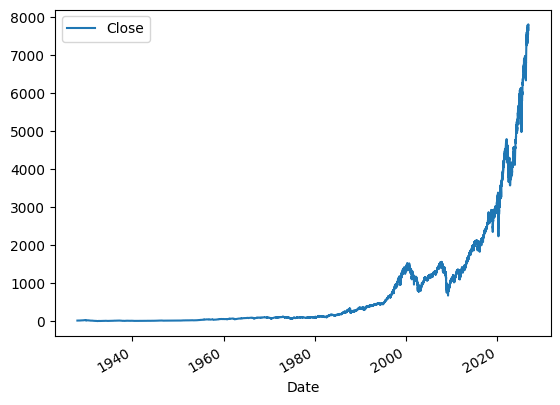

In [ ]:
sp500.plot.line(y="Close", use_index=True)

In [ ]:
del sp500["Dividends"]
del sp500["Stock Splits"]

# Setting Up Our Target For Machine Learning

In [ ]:
sp500["Tomorrow"] = sp500["Close"].shift(-1)

In [ ]:
sp500

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2026-10-01 00:00:00-04:00,7666.470215,7684.750000,7616.779785,7666.450195,5783800000,7722.720215
2026-10-02 00:00:00-04:00,7726.240234,7754.669922,7700.509766,7722.720215,5277430000,7773.950195
2026-10-05 00:00:00-04:00,7730.859863,7794.350098,7727.589844,7773.950195,5840900000,7818.930176


In [ ]:
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)

In [ ]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0
...,...,...,...,...,...,...,...
2026-10-01 00:00:00-04:00,7666.470215,7684.750000,7616.779785,7666.450195,5783800000,7722.720215,1
2026-10-02 00:00:00-04:00,7726.240234,7754.669922,7700.509766,7722.720215,5277430000,7773.950195,1
2026-10-05 00:00:00-04:00,7730.859863,7794.350098,7727.589844,7773.950195,5840900000,7818.930176,1


In [ ]:
sp500 = sp500.loc["1990-01-01":].copy()

In [ ]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0
...,...,...,...,...,...,...,...
2026-10-01 00:00:00-04:00,7666.470215,7684.750000,7616.779785,7666.450195,5783800000,7722.720215,1
2026-10-02 00:00:00-04:00,7726.240234,7754.669922,7700.509766,7722.720215,5277430000,7773.950195,1
2026-10-05 00:00:00-04:00,7730.859863,7794.350098,7727.589844,7773.950195,5840900000,7818.930176,1


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier (n_estimators=100, min_samples_split=100, random_state=1)

train = sp500.iloc[:-100]
test = sp500.iloc[-100:]

predictors = ["Close", "Volume", "Open", "High", "Low"]
model.fit(train[predictors], train["Target"])

RandomForestClassifier(min_samples_split=100, random_state=1)

In [ ]:
from sklearn.metrics import precision_score

preds = model.predict(test[predictors])

In [ ]:
import pandas as pd
preds = pd.Series(preds, index=test.index)

In [ ]:
preds

,0
Date,
2026-05-15 00:00:00-04:00,0
2026-05-18 00:00:00-04:00,0
2026-05-19 00:00:00-04:00,0
2026-05-20 00:00:00-04:00,0
2026-05-21 00:00:00-04:00,0
...,...
2026-10-01 00:00:00-04:00,0
2026-10-02 00:00:00-04:00,0
2026-10-05 00:00:00-04:00,0


In [ ]:
precision_score(test["Target"], preds)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


0.0

In [ ]:
combined = pd.concat([test["Target"], preds], axis=1)

<Axes: xlabel='Date'>

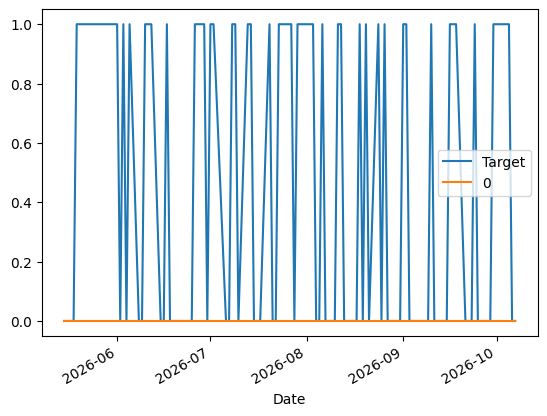

In [ ]:
combined.plot()

In [ ]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

In [ ]:
def backtest(data, model, predictors, start=2500, step=250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)
    return pd.concat(all_predictions)

In [ ]:
predictions = backtest(sp500, model, predictors)

In [ ]:
predictions["Predictions"].value_counts()

,count
Predictions,
0,4077
1,2682


In [ ]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5313199105145414

In [ ]:
predictions["Target"].value_counts() / predictions.shape[0]

,count
Target,
1,0.536914
0,0.463086


### Feature Engineering & Rolling Predictors

In financial time series forecasting, absolute prices (like `Close` or `Open`) are often non-stationary and carry less predictive power on their own. To give our Machine Learning models the temporal context needed to capture trends and momentum, we construct **rolling predictors**.

We utilize five distinct historical horizons—representing different market cycles:
* **2 Days**: Ultra-short-term momentum and immediate mean reversion.
* **5 Days**: Weekly trend, capturing short-term swing patterns.
* **60 Days**: Quarterly trend (approx. 3 months of trading), representing medium-term cyclical movements.
* **250 Days**: Yearly trend (approx. 1 year of trading), capturing major macroeconomic shifts and longer-term market sentiment.
* **1000 Days**: Multi-year trend (approx. 4 years of trading), showing secular bull or bear cycles.

For each horizon $X$, we engineer two features:

1. **Close Price Ratio (`Close_Ratio_X`)**:
   $$\text{Close\_Ratio\_X} = \frac{\text{Close}_t}{\text{Rolling\_Mean}(\text{Close}, X)_t}$$
   This indicates whether the current price is trading at a premium or discount relative to its historical average over the horizon $X$.

2. **Trend Accumulation (`Trend_X`)**:
   $$\text{Trend\_X} = \sum_{i=1}^{X} \text{Target}_{t-i}$$
   This calculates the sum of days the S&P 500 went up over the last $X$ days (shifted by 1 day to prevent data leakage). It acts as a proxy for historical upward momentum.

In [ ]:
horizons = [2,5,60,250,1000]
new_predictions = []

for horizon in horizons:
  rolling_averages = sp500.rolling(horizon).mean()

  ratio_column = f"Close_Ratio_{horizon}"
  sp500[ratio_column] = sp500["Close"] / rolling_averages["Close"]

  trend_column = f"Trend_{horizon}"
  sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()["Target"]
  new_predictions += [ratio_column, trend_column]

In [ ]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0,0.998706,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0,0.995675,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1,0.995098,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0,1.002252,1.0,0.993731,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-10-01 00:00:00-04:00,7666.470215,7684.750000,7616.779785,7666.450195,5783800000,7722.720215,1,1.000973,1.0,0.997822,2.0,1.004863,27.0,1.075329,133.0,1.372318,545.0
2026-10-02 00:00:00-04:00,7726.240234,7754.669922,7700.509766,7722.720215,5277430000,7773.950195,1,1.003656,2.0,1.005687,2.0,1.011843,27.0,1.082610,133.0,1.381407,546.0
2026-10-05 00:00:00-04:00,7730.859863,7794.350098,7727.589844,7773.950195,5840900000,7818.930176,1,1.003306,2.0,1.009984,3.0,1.018113,27.0,1.089160,133.0,1.389543,547.0


In [ ]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=500, random_state=1)

In [ ]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict_proba(test[predictors])[:,1]
    preds[preds >=.6] = 1
    preds[preds <.6] = 0
    preds= pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

In [ ]:
predictions = backtest(sp500, model, new_predictions)

In [ ]:
predictions["Predictions"].value_counts()

,count
Predictions,
0.0,6397
1.0,362


In [ ]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5359116022099447

### Evaluating and Testing the Model's Performance
Now that the backtest has finished running with our rolling-horizon predictors and a decision threshold of **60%** (via `predict_proba`), let's evaluate how well the model performed.

In [ ]:
# 1. Compute the precision score
precision = precision_score(predictions["Target"], predictions["Predictions"])
print(f"Model Precision Score: {precision:.2%}")

# 2. Show the distribution of predictions
print("\nPrediction Distribution:")
display(predictions["Predictions"].value_counts())

# 3. Compare with the market's baseline (Buy & Hold probability)
baseline = predictions["Target"].value_counts() / predictions.shape[0]
print("\nActual Market Direction Distribution (Baseline):")
display(baseline)

Model Precision Score: 53.59%

Prediction Distribution:


,count
Predictions,
0.0,6397
1.0,362



Actual Market Direction Distribution (Baseline):


,count
Target,
1,0.536914
0,0.463086


Let's plot the last 100 days of our backtest predictions against the actual market direction to visually inspect when our model issued buy signals (`1.0`).

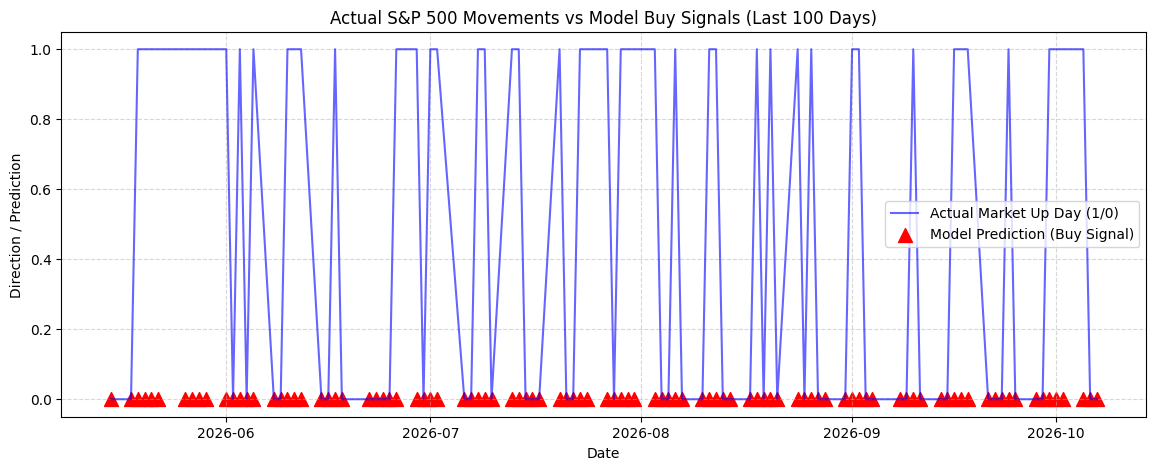

In [ ]:
import matplotlib.pyplot as plt

# Grab the last 100 days of predictions for visual checking
test_subset = predictions.iloc[-100:]

plt.figure(figsize=(14, 5))
plt.plot(test_subset.index, test_subset["Target"], label="Actual Market Up Day (1/0)", alpha=0.6, color="blue")
plt.scatter(test_subset.index, test_subset["Predictions"], label="Model Prediction (Buy Signal)", color="red", marker="^", s=100)
plt.title("Actual S&P 500 Movements vs Model Buy Signals (Last 100 Days)")
plt.xlabel("Date")
plt.ylabel("Direction / Prediction")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Making a Live Stock Prediction for the Next Trading Day
To predict whether the stock index will go up tomorrow, we fetch the latest available row from our dataset (representing today's closing market conditions) and check the model's confidence.

In [ ]:
# 1. Train the final model on all available data (excluding the very last row which doesn't have a known 'Tomorrow' target yet)
final_train = sp500.dropna().copy()
model.fit(final_train[new_predictions], final_train["Target"])

# 2. Extract the absolute latest day's features to predict for the next trading session
latest_day_features = sp500[new_predictions].iloc[[-1]]
latest_date = latest_day_features.index[0]

# 3. Predict the probability of the index going up
up_probability = model.predict_proba(latest_day_features)[0, 1]

# 4. Apply our custom 60% confidence threshold
prediction = 1 if up_probability >= 0.6 else 0

print(f"Latest Date in Dataset: {latest_date.strftime('%Y-%m-%d')}")
print(f"Probability of S&P 500 going UP on the next trading day: {up_probability:.2%}")
if prediction == 1:
    print("\n🟢 MATCHES BUY CRITERIA: The model is highly confident (>= 60%) that the market will close UP tomorrow!")
else:
    print("\n🔴 DO NOT BUY: The model is NOT confident (< 60%) that the market will close UP tomorrow.")

Latest Date in Dataset: 2026-10-07
Probability of S&P 500 going UP on the next trading day: 52.32%

🔴 DO NOT BUY: The model is NOT confident (< 60%) that the market will close UP tomorrow.
